# Analisi Testuale delle Risposte Aperte
## Topic Modeling, Reti Neurali e Modelli Pre-addestrati

Questo notebook applica tre approcci complementari alle risposte aperte:

**Parte 1 — Topic Modeling con LDA**  
Identifica i *temi ricorrenti* (contesto sociale, accademico, lavorativo) senza presupporre un esito emotivo.

**Parte 2 — Rete Neurale LSTM**  
Costruisce un classificatore di topic con Embedding + LSTM + Dense. Scopo didattico: architettura, training curve, embedding visualization.

**Parte 3 — Modello Pre-addestrato (feel-it)**  
Applica BERT italiano per riconoscere l'emozione prevalente (gioia, tristezza, paura, rabbia).

> **Nota metodologica**: una sentiment analysis positivo/negativo su Item\_30 (*"In quali situazioni ti senti ansioso?"*) è circolare — qualunque risposta che descriva ansia verrà classificata negativa. LDA e feel-it estraggono invece informazioni *non ovvie*.

## 1. Setup e Caricamento Librerie

In [94]:
import pandas as pd
import numpy as np
import mysql.connector
from mysql.connector import Error
import json
import re
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 2. Caricamento e Esplorazione dei Dati

In [95]:
import subprocess, sys

result_setup = subprocess.run([sys.executable, '../script/setup_raw_data.py'],
                              capture_output=True, text=True)
print(result_setup.stdout)
if result_setup.stderr:
    print("STDERR:", result_setup.stderr)

result_clean = subprocess.run([
    sys.executable, '-m', 'nbconvert',
    '--to', 'notebook', '--execute',
    '--ExecutePreprocessor.timeout=600',
    '../notebook/pulizia.ipynb'
], capture_output=True, text=True, cwd='.')

print(result_clean.stdout)
if result_clean.stderr:
    print("STDERR:", result_clean.stderr)


Creazione tabella raw_data...
Tabella raw_data creata

Credenziali caricate!
Credenziali caricate da: c:\Users\Utente\OneDrive - ITS Tech Talent Factory\Project Work\Project-Work\script\..\local\analisi-ansia-dcecdb75c868.json

Connessione a Google Sheets...
Trovate 170 risposte
Numero colonne: 39

Inizio importazione dati in raw_data...


Importazione completata!
   - Righe inserite: 170
   - Righe saltate: 0

Fine

STDERR: c:\Users\Utente\OneDrive - ITS Tech Talent Factory\Project Work\Project-Work\venv\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.10) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


STDERR: [NbConvertApp] Converting notebook ../notebook/pulizia.ipynb to n

In [96]:
import sys
sys.path.append('..')
from script.connessioni import get_mysql_connection

conn = get_mysql_connection()
df = pd.read_sql("SELECT * FROM clean_data", conn)
conn.close()

print(f"Dataset caricato: {df.shape[0]} righe, {df.shape[1]} colonne")
df.head()

Dataset caricato: 148 righe, 37 colonne


,id,email,contesto,età,genere,area_geo,anni_esperienza,Item_1,Item_2,Item_3,...,Item_21,Item_22,Item_23,Item_24,Item_25,Item_26,Item_27,Item_28,Item_29,Item_30
0,1,None,Entrambi,24,Femmina,Nord Italia,5.0,4,5,4,...,5,5,1,1,2,2,4,5,5,Durante gli esami e se devo interagire con gli...
1,2,None,Studio,26,Femmina,Nord Italia,7.0,4,5,3,...,4,1,3,3,5,2,2,2,4,Durante gli esami
2,3,None,Lavoro,26,Maschio,Nord Italia,5.0,3,4,3,...,3,5,1,1,4,2,5,4,5,Interazione con persone (clienti)
3,4,None,Entrambi,26,Femmina,Nord Italia,5.0,2,4,3,...,2,5,3,3,2,3,2,1,3,L’esame
4,5,None,Studio,22,Femmina,Nord Italia,2.0,3,2,3,...,2,2,3,2,4,3,3,2,4,"Durante il tirocinio, quando devo mettere effe..."


## 3. Preprocessing del Testo

In [97]:
def preprocess_text(text):
    """Lowercasing, rimozione URL/email/simboli, mantiene accenti italiani."""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[^a-z\u00e0-\u00fc0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

sample = "L'ansia mi causa problemi nelle situazioni sociali!"
print(f"Originale:    {sample}")
print(f"Preprocessed: {preprocess_text(sample)}")

Originale:    L'ansia mi causa problemi nelle situazioni sociali!
Preprocessed: lansia mi causa problemi nelle situazioni sociali


In [98]:
if df is not None:
    text_columns = []
    for col in df.columns:
        if df[col].dtype == 'object':
            non_null = df[col].dropna()
            if len(non_null) > 0:
                avg_length = non_null.astype(str).str.len().mean()
                if avg_length > 50:
                    text_columns.append(col)
                    print(f"{col}: {len(non_null)} risposte, lunghezza media: {avg_length:.0f} caratteri")

    if len(text_columns) == 0:
        print("Nessuna colonna testo trovata. Uso dataset sintetico per demo.")
        demo = [
            "durante gli esami e se devo interagire con gli insegnanti e i colleghi",
            "durante gli esami", "interazione con persone clienti",
            "durante il tirocinio quando devo mettere effettivamente in pratica",
            "durante una attivita di aggiornamento sistema al lavoro",
            "quando devo parlare in pubblico davanti alla classe",
            "in situazioni sociali con persone che non conosco bene",
            "quando devo chiedere informazioni o aiuto a qualcuno",
            "durante le riunioni quando devo esprimere la mia opinione",
            "quando sbaglio qualcosa davanti agli altri in classe",
            "in situazioni competitive come concorsi o selezioni",
            "quando il responsabile mi osserva mentre lavoro",
            "durante le verifiche scritte e le presentazioni orali",
            "in contesti dove devo dimostrare le mie competenze",
            "quando devo fare una telefonata formale o importante",
        ] * 5
        df_texts = pd.DataFrame({'text': demo})
    else:
        df['combined_text'] = df[text_columns].apply(
            lambda row: ' '.join([str(x) for x in row if pd.notna(x)]), axis=1)
        df_texts = df[df['combined_text'].str.len() > 10][['combined_text']].copy()
        df_texts.columns = ['text']
        print(f"\nRisposte aperte trovate: {len(df_texts)}")

    df_texts['text_clean'] = df_texts['text'].apply(preprocess_text)
    df_texts = df_texts[df_texts['text_clean'].str.len() > 3].copy().reset_index(drop=True)
    print(f"Testi dopo preprocessing: {len(df_texts)}")
    print("\nEsempi:")
    for t in df_texts['text_clean'].head(4).values:
        print(f"  · {t}")

Item_30: 148 risposte, lunghezza media: 58 caratteri

Risposte aperte trovate: 72
Testi dopo preprocessing: 72

Esempi:
  · durante gli esami e se devo interagire con gli insegnanti e i colleghi
  · durante gli esami
  · interazione con persone clienti
  · durante il tirocinio quando devo mettere effettivamente in pratica le cose che ho studiato


---
## Parte 1 — Topic Modeling con LDA

La **Latent Dirichlet Allocation (LDA)** è un modello probabilistico non supervisionato:
- ogni documento è una *miscela* di topic latenti
- ogni topic è una *distribuzione* sulle parole del vocabolario

Non ha etichette predefinite: scopre la struttura tematica direttamente dai dati.

**Scelta del numero di topic**: viene testato un range di valori e si sceglie quello che minimizza la perplexity.

In [99]:
STOPWORDS_IT = {
    'a', 'ad', 'al', 'allo', 'alla', 'agli', 'alle', 'ai',
    'con', 'col', 'coi', 'del', 'dello', 'della', 'dei', 'degli', 'delle',
    'dal', 'dallo', 'dalla', 'dai', 'dagli', 'dalle',
    'nel', 'nello', 'nella', 'nei', 'negli', 'nelle',
    'sul', 'sullo', 'sulla', 'sui', 'sugli', 'sulle',
    'di', 'da', 'in', 'su', 'per', 'tra', 'fra',
    'e', 'o', 'ma', 'se', 'che', 'ed', 'non',
    'il', 'lo', 'la', 'i', 'gli', 'le', 'un', 'uno', 'una',
    'io', 'tu', 'lui', 'lei', 'noi', 'voi', 'loro',
    'mi', 'ti', 'ci', 'vi', 'si', 'ne', 'li',
    'ho', 'hai', 'ha', 'abbiamo', 'avete', 'hanno',
    'sono', 'sei', 'siamo', 'siete',
    'anche', 'come', 'quando', 'dove', 'perche', 'pero',
    'piu', 'meno', 'molto', 'poco', 'tanto', 'troppo',
    'questo', 'questa', 'questi', 'queste',
    'quello', 'quella', 'quelli', 'quelle',
    'qui', 'qua', 'mio', 'mia', 'tuo', 'tua', 'suo', 'sua',
    'ogni', 'tutti', 'tutte', 'tutto', 'tutta',
    'altri', 'altre', 'altro', 'altra',
    'stesso', 'stessa', 'stessi', 'stesse',
    'fa', 'fai', 'fanno', 'fatto', 'fare',
    'puo', 'devo', 'vuole', 'vuoi', 'devi', 'deve',
    'stato', 'stata', 'stati', 'stare', 'essere', 'avere',
    'me', 'te', 'gia', 'poi', 'ben', 'mai',
}
print(f"Stopwords italiane: {len(STOPWORDS_IT)} parole")

Stopwords italiane: 146 parole


In [100]:
vectorizer_lda = CountVectorizer(
    max_df=0.95, min_df=1,
    stop_words=list(STOPWORDS_IT),
    ngram_range=(1, 2),
    max_features=500
)
X_counts = vectorizer_lda.fit_transform(df_texts['text_clean'])
feature_names = vectorizer_lda.get_feature_names_out()

print(f"Matrice documenti-termini: {X_counts.shape}")
freq = np.asarray(X_counts.sum(axis=0)).flatten()
top_idx = freq.argsort()[-20:][::-1]
print("\nTop 20 termini piu' frequenti:")
for i in top_idx:
    print(f"  {feature_names[i]:30s} {int(freq[i]):4d}")

Matrice documenti-termini: (72, 500)

Top 20 termini piu' frequenti:
  ansia                            12
  esame                            11
  durante                          11
  pubblico                          9
  parlare                           9
  davanti                           9
  prima                             9
  paura                             8
  lavoro                            8
  esami                             8
  situazioni                        7
  cui                               7
  lansia                            6
  situazione                        6
  riesco                            5
  studio                            5
  qualcosa                          5
  durante esami                     5
  mie                               4
  massimo                           4


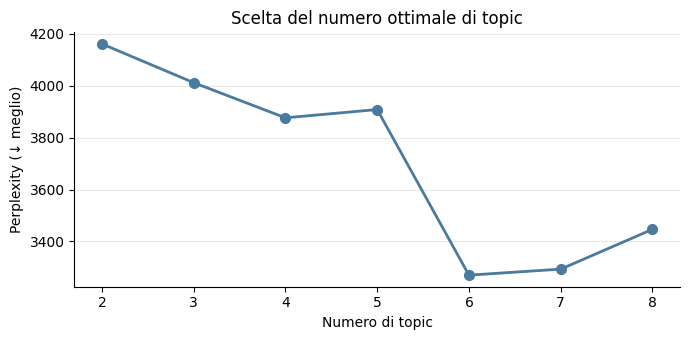

Perplexity per n_topics:
  n=2: 4161.4
  n=3: 4012.0
  n=4: 3876.5
  n=5: 3908.4
  n=6: 3270.2
  n=7: 3293.4
  n=8: 3446.8


In [101]:
n_range = range(2, 9)
perplexities = []
for n in n_range:
    lda_tmp = LatentDirichletAllocation(
        n_components=n, max_iter=30, learning_method='batch',
        random_state=42, doc_topic_prior=0.1, topic_word_prior=0.01)
    lda_tmp.fit(X_counts)
    perplexities.append(lda_tmp.perplexity(X_counts))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(list(n_range), perplexities, 'o-', color='#4A7A9E', lw=2, ms=7)
ax.set_xlabel('Numero di topic')
ax.set_ylabel('Perplexity (\u2193 meglio)')
ax.set_title('Scelta del numero ottimale di topic')
ax.set_xticks(list(n_range))
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../images/lda_perplexity.png', dpi=130, bbox_inches='tight')
plt.show()
print("Perplexity per n_topics:")
for n, p in zip(n_range, perplexities):
    print(f"  n={n}: {p:.1f}")

In [102]:
N_TOPICS = 4

lda = LatentDirichletAllocation(
    n_components=N_TOPICS, max_iter=100, learning_method='batch',
    random_state=42, doc_topic_prior=0.1, topic_word_prior=0.01)
lda.fit(X_counts)

print(f"LDA addestrata  {N_TOPICS} topic  perplexity: {lda.perplexity(X_counts):.1f}")
print()
print("Top 15 parole per topic:\n")
for i, topic_vec in enumerate(lda.components_):
    top_idx = topic_vec.argsort()[:-16:-1]
    words = [feature_names[j] for j in top_idx]
    print(f"  Topic {i+1}: {', '.join(words)}")
    print()

LDA addestrata  4 topic  perplexity: 3876.5

Top 15 parole per topic:

  Topic 1: durante, esame, lavoro, davanti, parlare, durante esami, cosa, affrontare, esami, persone, paura, soluzione, fallire, prova, parlare davanti

  Topic 2: pubblico, ansia, prima, davanti, parlare, cui, situazione, colleghi, mie, lavoro, situazioni, senza, parlare pubblico, esami, esame

  Topic 3: situazioni, paura, esame, prima, conosco, nuovo, superiore, ancora, partecipanti, lansia, miei, comunque, cui, ansia, compito

  Topic 4: orali, durante, studio, presentazioni, qualcosa, lansia, più, paura, ansia, esami, compromessi, sta, esami orali, pubblico, massimo



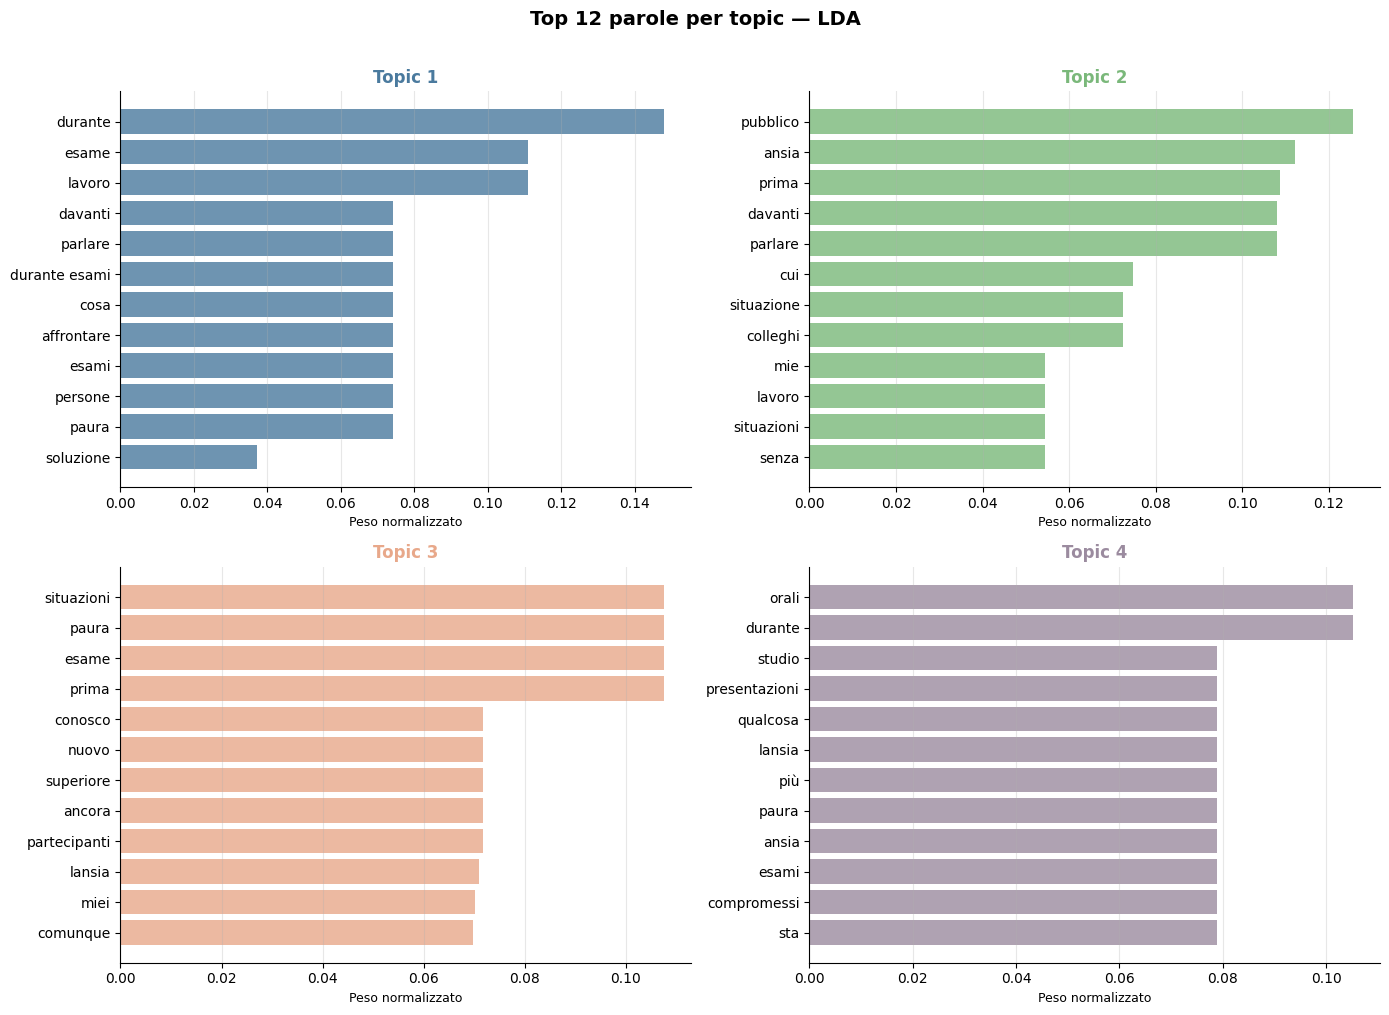

In [103]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ['#4A7A9E', '#7AB87A', '#E8A88A', '#9B8B9F']

for i, (ax, topic_vec) in enumerate(zip(axes, lda.components_)):
    top_n = 12
    top_idx = topic_vec.argsort()[:-top_n - 1:-1]
    words = [feature_names[j] for j in top_idx]
    scores_norm = topic_vec[top_idx] / topic_vec[top_idx].sum()
    ax.barh(range(top_n), scores_norm[::-1], color=colors[i], alpha=0.8)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(words[::-1], fontsize=10)
    ax.set_xlabel('Peso normalizzato', fontsize=9)
    ax.set_title(f'Topic {i+1}', fontsize=12, fontweight='bold', color=colors[i])
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Top 12 parole per topic — LDA', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../images/lda_topic_words.png', dpi=130, bbox_inches='tight')
plt.show()

In [104]:
doc_topic_matrix = lda.transform(X_counts)
df_texts['topic'] = doc_topic_matrix.argmax(axis=1) + 1
df_texts['topic_confidence'] = doc_topic_matrix.max(axis=1)
for i in range(N_TOPICS):
    df_texts[f'p_topic{i+1}'] = doc_topic_matrix[:, i]

print("Distribuzione topic:\n")
for t, cnt in df_texts['topic'].value_counts().sort_index().items():
    pct = cnt / len(df_texts) * 100
    #print(f"  Topic {t}: {cnt:3d} ({pct:.1f}%)  {'\u2588' * int(pct/2)}")

print(f"\nConfidenza media: {df_texts['topic_confidence'].mean():.2f}")
print("\nEsempi per topic:")
for t in range(1, N_TOPICS + 1):
    sample = df_texts[df_texts['topic'] == t].nlargest(2, 'topic_confidence')
    print(f"\n  Topic {t}:")
    for _, row in sample.iterrows():
        print(f"    [{row['topic_confidence']:.2f}] {row['text'][:100]}")

Distribuzione topic:


Confidenza media: 0.94

Esempi per topic:

  Topic 1:
    [0.98] Non ho ansia intesa come paura di fallire quanto di non riuscire a finire quello che sto facendo, so
    [0.97] Quando il risultato della prova influisce sulla mia indipendenza/libertà (Es. esame patente)

  Topic 2:
    [0.99] Tutte le situazioni descritte prima quindi se devo parlare in pubblico o devo dimostrare comunque le
    [0.99] Prima di qualsiasi situazione in cui ci siano diverse persone a guardarmi e, in generale, dove sono 

  Topic 3:
    [0.99] 2 situazioni: quando so che la reazione dell'altra persona (es: un superiore) ad un errore potrebbe 
    [0.98] Situazioni in cui devo affrontare colloqui che determinano la mia reputazione o la mia carriera lavo

  Topic 4:
    [0.99] Nel mio caso è una situazione legata all’università. Gli esami orali per me sono molto complicati, n
    [0.99] L'ansia sta condizionando la mia vita ormai, gradualmente sta diventando sempre più presente e invas

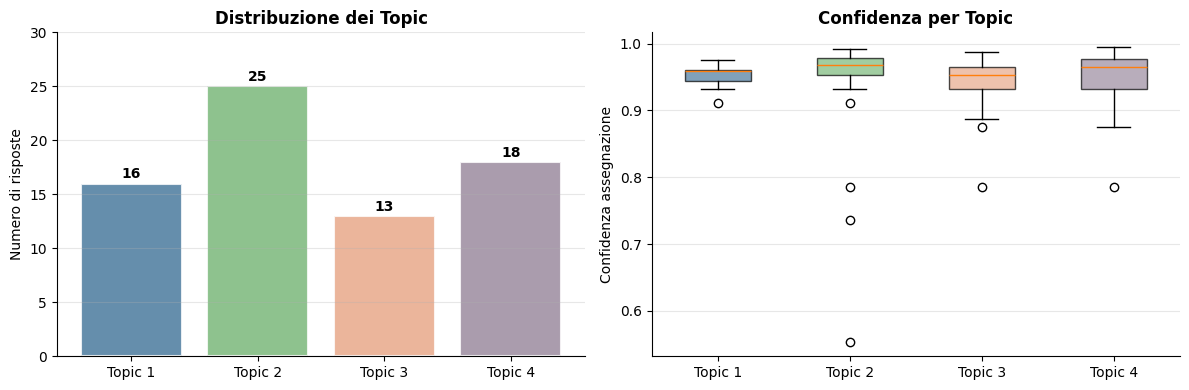

In [105]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#4A7A9E', '#7AB87A', '#E8A88A', '#9B8B9F']
counts = [len(df_texts[df_texts['topic'] == t]) for t in range(1, N_TOPICS + 1)]
bars = ax1.bar([f'Topic {t}' for t in range(1, N_TOPICS + 1)], counts,
               color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, cnt in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
             str(cnt), ha='center', va='bottom', fontweight='bold')
ax1.set_ylabel('Numero di risposte')
ax1.set_title('Distribuzione dei Topic', fontweight='bold')
ax1.set_ylim(0, max(counts) * 1.2)
ax1.grid(axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

data_bp = [df_texts[df_texts['topic'] == t]['topic_confidence'].values
           for t in range(1, N_TOPICS + 1)]
bp = ax2.boxplot(data_bp, patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax2.set_xticklabels([f'Topic {t}' for t in range(1, N_TOPICS + 1)])
ax2.set_ylabel('Confidenza assegnazione')
ax2.set_title('Confidenza per Topic', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../images/lda_topic_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

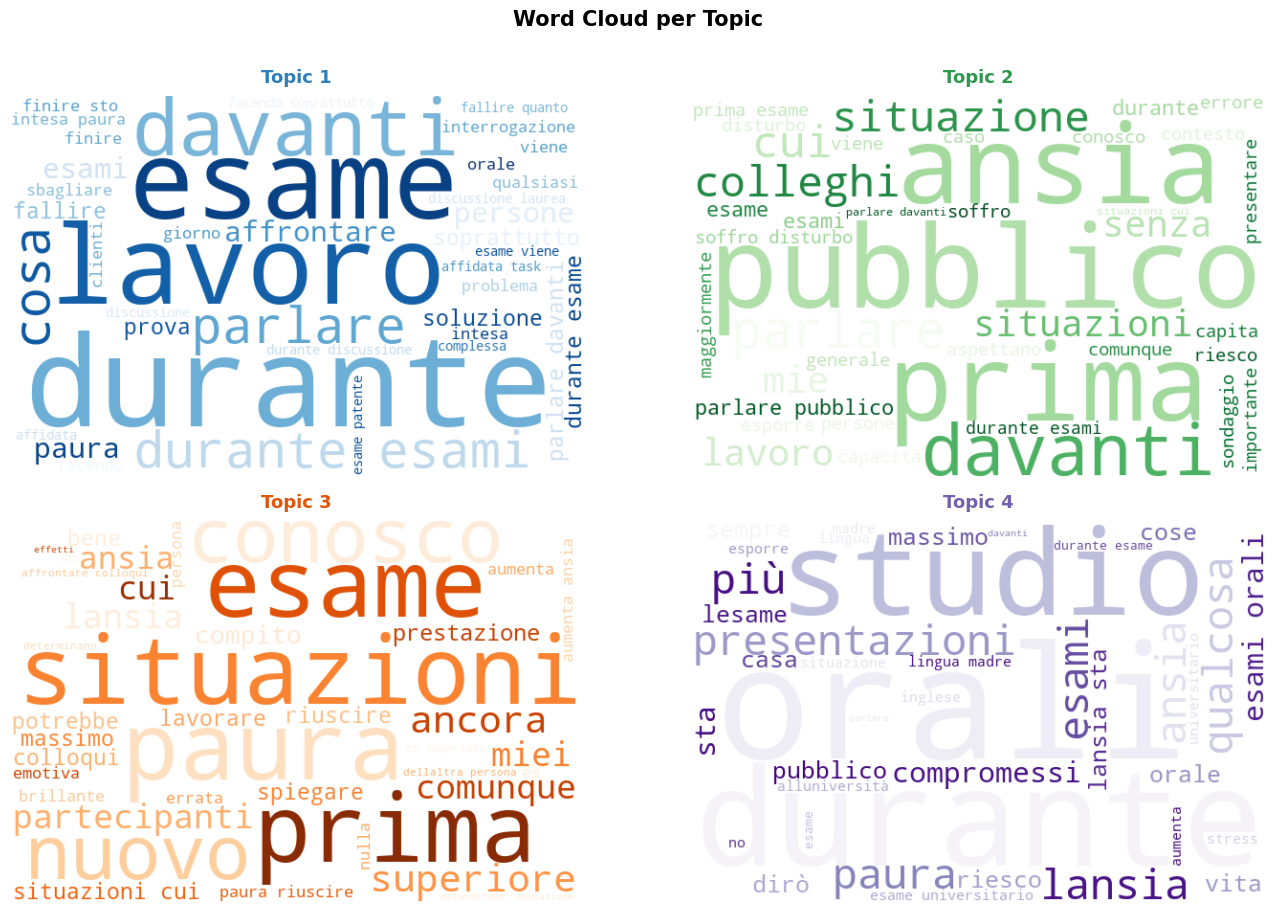

In [106]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
colormaps = ['Blues', 'Greens', 'Oranges', 'Purples']
for i in range(N_TOPICS):
    topic_vec = lda.components_[i]
    word_weights = {feature_names[j]: float(topic_vec[j])
                    for j in topic_vec.argsort()[-50:][::-1]}
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=colormaps[i], max_words=40,
                   prefer_horizontal=0.9).generate_from_frequencies(word_weights)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'Topic {i+1}', fontsize=13, fontweight='bold', pad=10,
                      color=plt.get_cmap(colormaps[i])(0.7))
plt.suptitle('Word Cloud per Topic', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../images/lda_wordclouds.png', dpi=130, bbox_inches='tight')
plt.show()

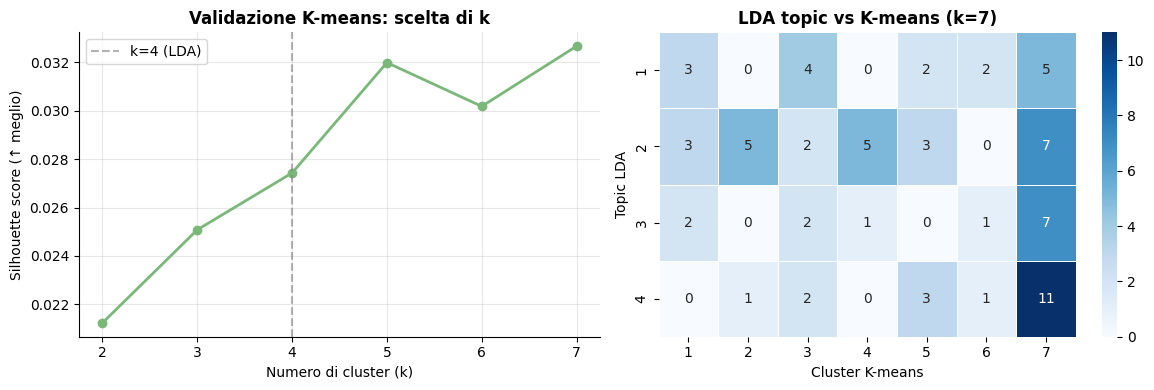

K-means ottimale: k=7  silhouette=0.033


In [107]:
from sklearn.preprocessing import normalize
tfidf = TfidfVectorizer(stop_words=list(STOPWORDS_IT),
                        max_features=300, ngram_range=(1, 2))
X_tfidf = normalize(tfidf.fit_transform(df_texts['text_clean']).toarray())

sil_scores = []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    sil_scores.append(silhouette_score(X_tfidf, km.fit_predict(X_tfidf)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(k_range), sil_scores, 'o-', color='#7AB87A', lw=2, ms=6)
ax1.axvline(x=N_TOPICS, color='gray', linestyle='--', alpha=0.6,
            label=f'k={N_TOPICS} (LDA)')
ax1.set_xlabel('Numero di cluster (k)')
ax1.set_ylabel('Silhouette score (\u2191 meglio)')
ax1.set_title('Validazione K-means: scelta di k', fontweight='bold')
ax1.legend(); ax1.grid(alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_texts['cluster_km'] = km_best.fit_predict(X_tfidf) + 1
ct = pd.crosstab(df_texts['topic'], df_texts['cluster_km'],
                 rownames=['Topic LDA'], colnames=['Cluster K-means'])
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax2)
ax2.set_title(f'LDA topic vs K-means (k={best_k})', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/lda_kmeans_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"K-means ottimale: k={best_k}  silhouette={max(sil_scores):.3f}")

In [108]:
import os
os.makedirs('../output', exist_ok=True)
cols_out = ['text', 'text_clean', 'topic', 'topic_confidence']
cols_out += [f'p_topic{i+1}' for i in range(N_TOPICS)]
df_texts[cols_out].to_csv('../output/topic_modeling_results.csv',
                          index=False, encoding='utf-8-sig')
print("Salvato: ../output/topic_modeling_results.csv")
df_texts[cols_out].head()

Salvato: ../output/topic_modeling_results.csv


,text,text_clean,topic,topic_confidence,p_topic1,p_topic2,p_topic3,p_topic4
0,Durante gli esami e se devo interagire con gli...,durante gli esami e se devo interagire con gli...,2,0.968081,0.010641,0.968081,0.010638,0.010640
1,Durante gli esami,durante gli esami,1,0.911755,0.911755,0.029416,0.029412,0.029417
2,Interazione con persone (clienti),interazione con persone clienti,1,0.931816,0.931816,0.022728,0.022729,0.022727
3,"Durante il tirocinio, quando devo mettere effe...",durante il tirocinio quando devo mettere effet...,2,0.953117,0.015628,0.953117,0.015625,0.015629
4,Durate una attivtà di aggiornamento sistema al...,durate una attivtà di aggiornamento sistema al...,1,0.959459,0.959459,0.013514,0.013514,0.013514


---
## Parte 2 — Rete Neurale LSTM

Costruiamo un classificatore LSTM con TensorFlow/Keras per predire il **topic** (etichette LDA) direttamente dal testo grezzo.

Il pipeline ha tre stadi:
1. **Tokenizzazione** — ogni parola diventa un indice intero
2. **Embedding layer** — ogni indice viene mappato in un vettore denso *appreso durante il training*
3. **LSTM** — elabora la sequenza mantenendo uno stato nascosto che cattura dipendenze a lungo termine

> **Nota sui dati**: con 72 campioni il modello non può generalizzare in modo affidabile. L'obiettivo è *didattico*: mostrare architettura, training pipeline, curve di apprendimento e visualizzazione degli embedding. Con dataset reali di migliaia di esempi i risultati sarebbero significativi.

In [109]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow: {tf.__version__}")
print(f"GPU disponibili: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.19.1
GPU disponibili: []


In [110]:
MAX_WORDS    = 500
MAX_SEQ_LEN  = 30
EMBEDDING_DIM = 32

labels     = (df_texts['topic'] - 1).values
texts_raw  = df_texts['text_clean'].tolist()

tokenizer_lstm = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer_lstm.fit_on_texts(texts_raw)
sequences  = tokenizer_lstm.texts_to_sequences(texts_raw)
X_padded   = pad_sequences(sequences, maxlen=MAX_SEQ_LEN,
                            padding='post', truncating='post')
vocab_size = min(len(tokenizer_lstm.word_index) + 1, MAX_WORDS)

print(f"Vocabolario reale: {len(tokenizer_lstm.word_index)} parole")
print(f"Vocabolario usato: {vocab_size}")
print(f"Shape input:       {X_padded.shape}  (n_campioni x lunghezza_sequenza)")
print()
print("Esempio tokenizzazione:")
print(f"  Testo:    {texts_raw[0]}")
print(f"  Sequenza: {sequences[0]}")
print(f"  Padded:   {X_padded[0][:15]}...")

Vocabolario reale: 538 parole
Vocabolario usato: 500
Shape input:       (72, 30)  (n_campioni x lunghezza_sequenza)

Esempio tokenizzazione:
  Testo:    durante gli esami e se devo interagire con gli insegnanti e i colleghi
  Sequenza: [20, 24, 31, 3, 42, 10, 174, 22, 24, 175, 3, 32, 56]
  Padded:   [ 20  24  31   3  42  10 174  22  24 175   3  32  56   0   0]...


In [111]:
y_cat = to_categorical(labels, num_classes=N_TOPICS)
X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y_cat, test_size=0.2, random_state=42, stratify=labels)

print(f"Training set: {X_train.shape[0]} campioni")
print(f"Test set:     {X_test.shape[0]} campioni")
print("\nDistribuzione topic nel training set:")
for t in range(N_TOPICS):
    cnt = (y_train.argmax(axis=1) == t).sum()
    pct = cnt / len(y_train) * 100
    print(f"  Topic {t+1}: {cnt:3d} ({pct:.1f}%)")

Training set: 57 campioni
Test set:     15 campioni

Distribuzione topic nel training set:
  Topic 1:  13 (22.8%)
  Topic 2:  20 (35.1%)
  Topic 3:  10 (17.5%)
  Topic 4:  14 (24.6%)


In [112]:
model = Sequential([
    # Embedding: trasforma indici in vettori densi appresi
    Embedding(input_dim=vocab_size,
              output_dim=EMBEDDING_DIM,
              input_length=MAX_SEQ_LEN),
    # LSTM: elabora la sequenza con memoria
    LSTM(units=64, dropout=0.3, recurrent_dropout=0.2),
    Dropout(0.3),
    # Hidden layer
    Dense(32, activation='relu'),
    Dropout(0.2),
    # Output multiclasse
    Dense(N_TOPICS, activation='softmax')
], name='LSTM_TopicClassifier')

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "LSTM_TopicClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [113]:
early_stop = EarlyStopping(monitor='val_loss', patience=10,
                           restore_best_weights=True, verbose=0)

history = model.fit(
    X_train, y_train,
    batch_size=16,
    epochs=80,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)
print(f"\nTraining completato a epoch {len(history.history['loss'])}")

Epoch 1/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 281ms/step - accuracy: 0.2444 - loss: 1.3902 - val_accuracy: 0.3333 - val_loss: 1.3841
Epoch 2/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1556 - loss: 1.3832 - val_accuracy: 0.4167 - val_loss: 1.3826
Epoch 3/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3111 - loss: 1.3777 - val_accuracy: 0.4167 - val_loss: 1.3812
Epoch 4/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3111 - loss: 1.3745 - val_accuracy: 0.4167 - val_loss: 1.3799
Epoch 5/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.2222 - loss: 1.3760 - val_accuracy: 0.4167 - val_loss: 1.3790
Epoch 6/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4000 - loss: 1.3470 - val_accuracy: 0.4167 - val_loss: 1.3785
Epoch 7/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4000 - loss: 1.3624 - val_accuracy: 0.4167 - val_loss: 1.3791
Epoch 8/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.2222 - loss: 1.3617 - val_accuracy: 0.4167 - val_loss: 1.3819

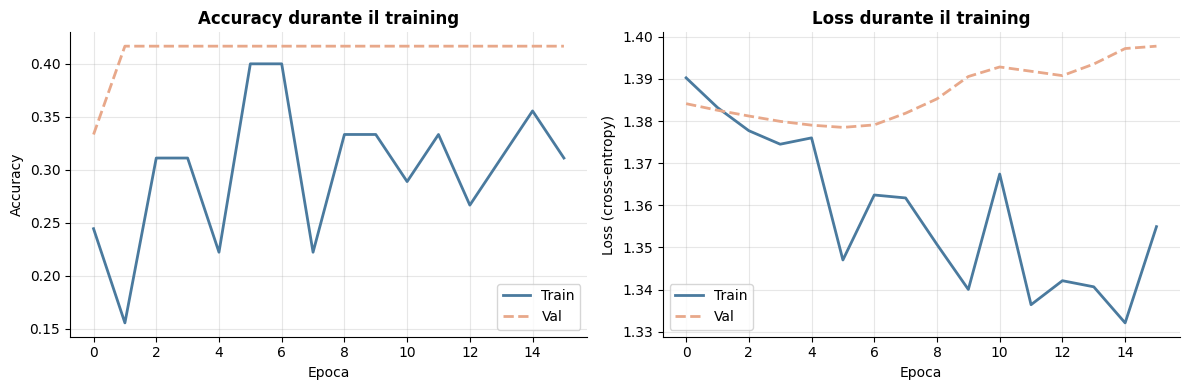

In [114]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'],     label='Train', color='#4A7A9E', lw=2)
ax1.plot(history.history['val_accuracy'], label='Val',   color='#E8A88A', lw=2, ls='--')
ax1.set_xlabel('Epoca'); ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy durante il training', fontweight='bold')
ax1.legend(); ax1.grid(alpha=0.3)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

ax2.plot(history.history['loss'],     label='Train', color='#4A7A9E', lw=2)
ax2.plot(history.history['val_loss'], label='Val',   color='#E8A88A', lw=2, ls='--')
ax2.set_xlabel('Epoca'); ax2.set_ylabel('Loss (cross-entropy)')
ax2.set_title('Loss durante il training', fontweight='bold')
ax2.legend(); ax2.grid(alpha=0.3)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../images/lstm_training_curves.png', dpi=130, bbox_inches='tight')
plt.show()

In [115]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
y_true = y_test.argmax(axis=1)
target_names = [f'Topic {i+1}' for i in range(N_TOPICS)]

print(f"Loss test:     {test_loss:.4f}")
print(f"Accuracy test: {test_acc:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

baseline = max((y_true == t).sum() for t in range(N_TOPICS)) / len(y_true)
print(f"Baseline (classe piu' frequente): {baseline:.4f}")
gain = (test_acc - baseline) * 100
print(f"{'Il modello supera' if gain > 0 else 'Il modello non supera'} "
      f"il baseline di {abs(gain):.1f} pp")

Loss test:     1.3805
Accuracy test: 0.2000

              precision    recall  f1-score   support

     Topic 1       0.21      1.00      0.35         3
     Topic 2       0.00      0.00      0.00         5
     Topic 3       0.00      0.00      0.00         3
     Topic 4       0.00      0.00      0.00         4

    accuracy                           0.20        15
   macro avg       0.05      0.25      0.09        15
weighted avg       0.04      0.20      0.07        15

Baseline (classe piu' frequente): 0.3333
Il modello non supera il baseline di 13.3 pp


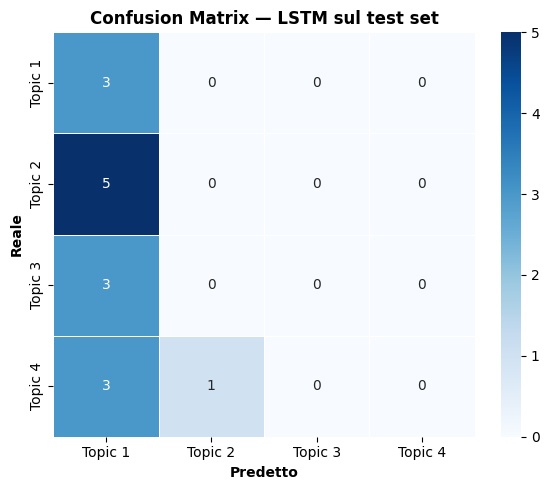

In [116]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predetto', fontweight='bold')
ax.set_ylabel('Reale', fontweight='bold')
ax.set_title('Confusion Matrix — LSTM sul test set', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/lstm_confusion_matrix.png', dpi=130, bbox_inches='tight')
plt.show()

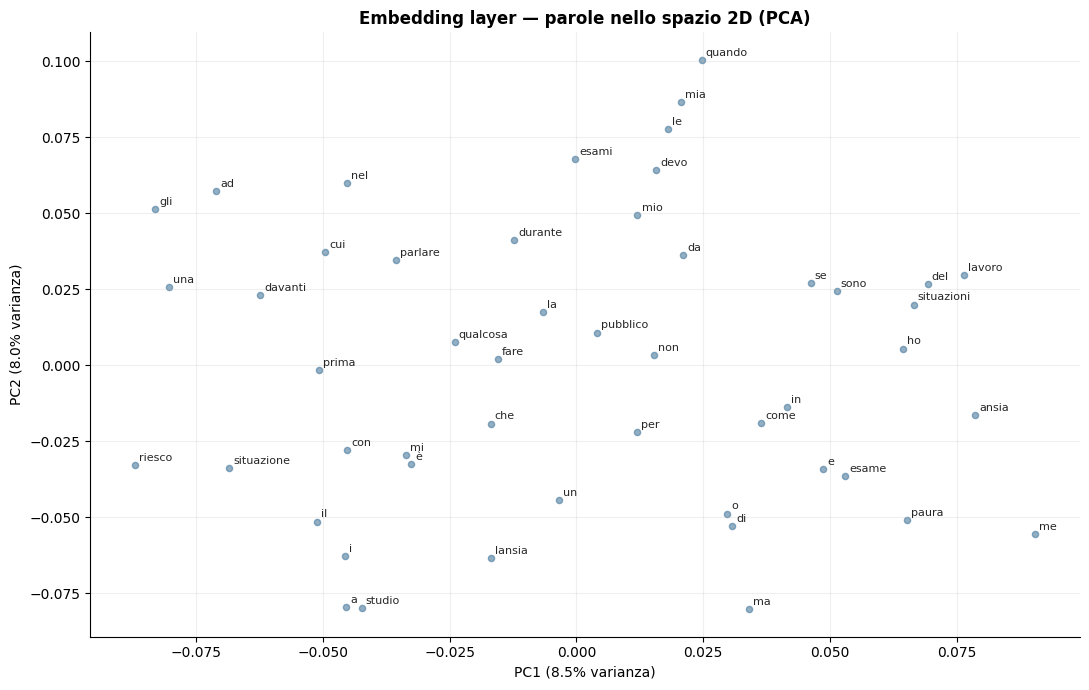

In [117]:
from sklearn.decomposition import PCA

emb_weights = model.layers[0].get_weights()[0]   # (vocab_size, EMBEDDING_DIM)

# Top 50 parole piu' frequenti (escludi <OOV>)
word_freq = sorted(tokenizer_lstm.word_counts.items(),
                   key=lambda x: x[1], reverse=True)
valid = [(w, c) for w, c in word_freq
         if tokenizer_lstm.word_index.get(w, 0) < vocab_size][:50]
words_top = [w for w, _ in valid]
word_ids  = [tokenizer_lstm.word_index[w] for w in words_top]
vectors   = emb_weights[word_ids]

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vectors)

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(coords[:, 0], coords[:, 1], s=20, alpha=0.6, color='#4A7A9E')
for i, word in enumerate(words_top):
    ax.annotate(word, (coords[i, 0], coords[i, 1]),
                fontsize=8, alpha=0.85,
                xytext=(3, 3), textcoords='offset points')
ax.set_title('Embedding layer — parole nello spazio 2D (PCA)',
             fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.grid(alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../output/lstm_embeddings_pca.png', dpi=130, bbox_inches='tight')
plt.show()

In [118]:
import pickle, os
os.makedirs('../output', exist_ok=True)

model.save('../output/lstm_topic_model.h5')
with open('../output/lstm_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer_lstm, f)
print("Modello salvato:   ../output/lstm_topic_model.h5")
print("Tokenizer salvato: ../output/lstm_tokenizer.pkl")

# Confronto LDA vs LSTM sull'intero corpus
y_all = model.predict(X_padded, verbose=0).argmax(axis=1) + 1
df_texts['lstm_topic'] = y_all
accordo = (df_texts['topic'] == df_texts['lstm_topic']).mean()
print(f"\nAccordo LDA-LSTM: {accordo*100:.1f}%")
ct = pd.crosstab(df_texts['topic'], df_texts['lstm_topic'],
                 rownames=['Topic LDA'], colnames=['Topic LSTM'])
print(ct)

Modello salvato:   ../output/lstm_topic_model.h5
Tokenizer salvato: ../output/lstm_tokenizer.pkl

Accordo LDA-LSTM: 30.6%
Topic LSTM   1  2
Topic LDA        
1           16  0
2           19  6
3           10  3
4           13  5


---
## Parte 3 — Modello Pre-addestrato: feel-it

Invece di addestrare un modello da zero, usiamo **feel-it**, un modello BERT fine-tuned su testo italiano che classifica le emozioni in: **gioia, tristezza, paura, rabbia**.

Modello: `MilaNLProc/feel-it-italian-sentiment`  
Richiede connessione internet al primo utilizzo (download ~400 MB).

> **Aspettativa**: anche con un modello robusto, Item\_30 darà prevalentemente paura/tristezza — è un artefatto della domanda. Il valore aggiunto è la *distribuzione* tra emozioni e la correlazione con i topic (Parte 1): mostra se certi contesti generano emozioni qualitativamente diverse.

In [119]:
'''import subprocess, sys
result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', 'transformers', 'torch', '--quiet'],
    capture_output=True, text=True)
print("transformers installato" if result.returncode == 0
      else f"Attenzione: {result.stderr[:200]}")'''

'import subprocess, sys\nresult = subprocess.run(\n    [sys.executable, \'-m\', \'pip\', \'install\', \'transformers\', \'torch\', \'--quiet\'],\n    capture_output=True, text=True)\nprint("transformers installato" if result.returncode == 0\n      else f"Attenzione: {result.stderr[:200]}")'

In [125]:
classifier = None
try:
    from transformers import pipeline
    classifier = pipeline(
        "text-classification",
        model="MilaNLProc/feel-it-italian-sentiment",
        top_k=None, truncation=True, max_length=128)
    print("Modello feel-it caricato")
    test = "Mi sento molto ansioso quando devo parlare in pubblico"
    result = classifier(test)[0]
    print(f"\nTest: '{test}'")
    print("Emozioni:")
    for r in sorted(result, key=lambda x: x['score'], reverse=True):
        print(f"  {r['label']:10s} {r['score']:.3f}") #  {'\u2588' * int(r['score']*25)}")
except Exception as e:
    print(f"feel-it non disponibile: {e}")
    try:
        from transformers import pipeline
        classifier = pipeline(
            "text-classification",
            model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
            top_k=None, truncation=True, max_length=128)
        print("Fallback caricato: cardiffnlp/twitter-xlm-roberta-base-sentiment")
    except Exception as e2:
        print(f"Fallback non disponibile: {e2}")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 25065.56it/s]


feel-it non disponibile: too many values to unpack (expected 2)


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 28133.72it/s]
[transformers] Could not extract SentencePiece model from C:\Users\Utente\.cache\huggingface\hub\models--cardiffnlp--twitter-xlm-roberta-base-sentiment\snapshots\f2f1202b1bdeb07342385c3f807f9c07cd8f5cf8\sentencepiece.bpe.model using sentencepiece library due to 
SentencePieceExtractor requires the SentencePiece library but it was not found in your environment. Check out the instructions on the
installation page of its repo: https://github.com/google/sentencepiece#installation and follow the ones
that match your environment. Please note that you may need to restart your runtime after installation.
. Falling back to TikToken extractor.


Fallback non disponibile: Error parsing line b'\x0e' in C:\Users\Utente\.cache\huggingface\hub\models--cardiffnlp--twitter-xlm-roberta-base-sentiment\snapshots\f2f1202b1bdeb07342385c3f807f9c07cd8f5cf8\sentencepiece.bpe.model


In [121]:
if classifier is not None:
    def classify_text(text):
        if not text or len(str(text).strip()) < 3:
            return {}
        try:
            return {r['label']: round(r['score'], 4)
                    for r in classifier(str(text)[:256])[0]}
        except Exception:
            return {}

    print("Classificazione in corso...")
    emotion_dicts = [classify_text(t) for t in df_texts['text']]
    all_labels = sorted({k for d in emotion_dicts for k in d})
    print(f"Etichette rilevate: {all_labels}")

    for label in all_labels:
        df_texts[f'emo_{label}'] = [d.get(label, 0.0) for d in emotion_dicts]
    df_texts['emotion_pred'] = [
        max(d, key=d.get) if d else 'unknown' for d in emotion_dicts]
    df_texts['emotion_confidence'] = [
        max(d.values()) if d else 0.0 for d in emotion_dicts]

    print("\nDistribuzione emozioni:")
    for emo, cnt in df_texts['emotion_pred'].value_counts().items():
        pct = cnt / len(df_texts) * 100
        print(f"  {emo:12s} {cnt:3d} ({pct:.1f}%)") # {'\u2588' * int(pct/3)}")
else:
    df_texts['emotion_pred'] = 'unavailable'
    df_texts['emotion_confidence'] = 0.0
    print("Classificatore non disponibile.")

Classificatore non disponibile.


In [122]:
if df_texts['emotion_pred'].iloc[0] != 'unavailable':
    emo_counts = df_texts['emotion_pred'].value_counts()
    emo_palette = {'joy':'#F6C26E','sadness':'#7AA8C4',
                   'fear':'#9B8EC4','anger':'#E07070',
                   'POSITIVE':'#7AB87A','NEGATIVE':'#E07070','NEUTRAL':'#A0A0A0'}
    colors_emo = [emo_palette.get(e, '#AAAAAA') for e in emo_counts.index]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.pie(emo_counts.values, labels=emo_counts.index,
            colors=colors_emo, autopct='%1.1f%%', startangle=140,
            pctdistance=0.75)
    ax1.set_title('Distribuzione Emozioni (feel-it)', fontweight='bold')

    emo_conf = df_texts.groupby('emotion_pred')['emotion_confidence'].mean()
    bars = ax2.bar(emo_conf.index, emo_conf.values,
                   color=[emo_palette.get(e,'#AAAAAA') for e in emo_conf.index],
                   alpha=0.85, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, emo_conf.values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.005,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax2.set_ylabel('Confidenza media'); ax2.set_ylim(0, 1.1)
    ax2.set_title('Confidenza Media per Emozione', fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('../images/emotion_distribution.png', dpi=130, bbox_inches='tight')
    plt.show()

In [123]:
if df_texts['emotion_pred'].iloc[0] != 'unavailable':
    print("Esempi per emozione (top 3 per confidenza):\n")
    for emo in df_texts['emotion_pred'].value_counts().index:
        subset = df_texts[df_texts['emotion_pred']==emo].nlargest(3,'emotion_confidence')
        print(f"  {'─'*50}\n  {emo.upper()}")
        for _, row in subset.iterrows():
            print(f"    [{row['emotion_confidence']:.2f}] {row['text'][:100]}")
        print()

In [124]:
if ('topic' in df_texts.columns
        and df_texts['emotion_pred'].iloc[0] != 'unavailable'):
    ct = pd.crosstab(df_texts['topic'], df_texts['emotion_pred'],
                     normalize='index') * 100
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.heatmap(ct, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=0.5, ax=ax,
                cbar_kws={'label': '% risposte nel topic'})
    ax.set_xlabel('Emozione (feel-it)', fontweight='bold')
    ax.set_ylabel('Topic LDA', fontweight='bold')
    ax.set_title('Distribuzione emotiva per topic\n(% per riga)',
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig('../images/topic_emotion_heatmap.png', dpi=130, bbox_inches='tight')
    plt.show()
    print("Emozione prevalente per topic:")
    for t in ct.index:
        dominant = ct.loc[t].idxmax()
        print(f"  Topic {t}: {dominant} ({ct.loc[t].max():.1f}%)")

---
## Conclusioni

### Cosa abbiamo trovato

**Parte 1 — Topic Modeling (LDA)**
- I topic rispecchiano i *contesti* che generano ansia: situazioni sociali, accademiche, lavorative, di performance
- Risultato non ovvio: permette di categorizzare i bisogni dei rispondenti

**Parte 2 — Rete Neurale LSTM**
- L'architettura Embedding+LSTM apprende rappresentazioni vettoriali delle parole *specifiche per il task*
- Con 72 campioni l'accuracy sul test set è orientativa; le curve di training e la PCA degli embedding hanno valore didattico
- Il confronto LDA vs LSTM mostra quanto i due approcci concordino sull'assegnazione dei topic

**Parte 3 — feel-it (BERT)**
- Conferma che la componente emotiva prevalente è paura/tristezza — atteso dalla struttura della domanda
- La heatmap topic×emozione mostra se certi contesti generano emozioni qualitativamente diverse

### Limiti
- Corpus piccolo (72 risposte): tutti i risultati vanno interpretati con cautela
- Item\_30 è una domanda guidata e produce selezione di contesti negativi
- Per un'analisi più ricca servirebbe una domanda neutra (*'descrivi la tua settimana tipica'*)